Для выполнения задания предлагается использовать выборку данных о недвижимости в Бостоне (источник: https://www.kaggle.com/code/prasadperera/the-boston-housing-dataset):

* CRIM - уровень преступности на душу населения по городам.
* ZN - доля жилых земель, зонированных на участки площадью более 25 000 кв. футов.
* INDUS - доля площадей под неторговую деятельность на город.
* CHAS - фиктивная переменная реки Чарльз (1, если участок граничит с рекой; 0 в противном случае).
* NOX - концентрация оксидов азота (частей на 10 миллионов).
* RM - среднее количество комнат в доме.
* AGE - доля квартир, занимаемых владельцами, построенных до 1940 г.
* DIS - взвешенные расстояния до пяти центров занятости Бостона.
* RAD - индекс доступности радиальных автомобильных дорог.
* TAX - ставка налога на имущество в размере полной стоимости за 10 000 долларов США.
* PTRATIO - соотношение учеников и учителей по районам
B - 1000(Bk - 0.63)^2, где Bk - доля чернокожих горожан в районе.
* LSTAT - % населения с более низким социальным статусом.
* MEDV - Средняя стоимость домов, занимаемых владельцами, в 1000 долларов США.

#Задание 1.
Загрузите данные по недвижимости в Бостоне.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline

#Задание 2.
Создайте датафрейм, добавьте целевую переменную и выведите первые семь строк. Разделите выборку на обучающую и тестовую части. Используйте одно и то же разделение для всех моделей регрессии (меняя при необходимости только количество учавствующих в обучении предикторов).

In [ ]:
# Создание датафрейма
df = pd.read_csv('/content/boston.csv')
y = df['MEDV'] # Добавление целевой переменной

# Вывод первых 7 строк
print(df.head(7))

# Разделение на обучающую и тестовую выборки (70/30)
X = df.drop('MEDV', axis=1)
y = df['MEDV']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900  1.0  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671  2.0  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671  2.0  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622  3.0  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622  3.0  222.0   
5  0.02985   0.0   2.18   0.0  0.458  6.430  58.7  6.0622  3.0  222.0   
6  0.08829  12.5   7.87   0.0  0.524  6.012  66.6  5.5605  5.0  311.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  
5     18.7  394.12   5.21  28.7  
6     15.2  395.60  12.43  22.9  


#Задание 3.1.
Постройте точечную диаграмму с переменными LSTAT, PTRATIO. Какие выводы можно сделать на основе этого графика?

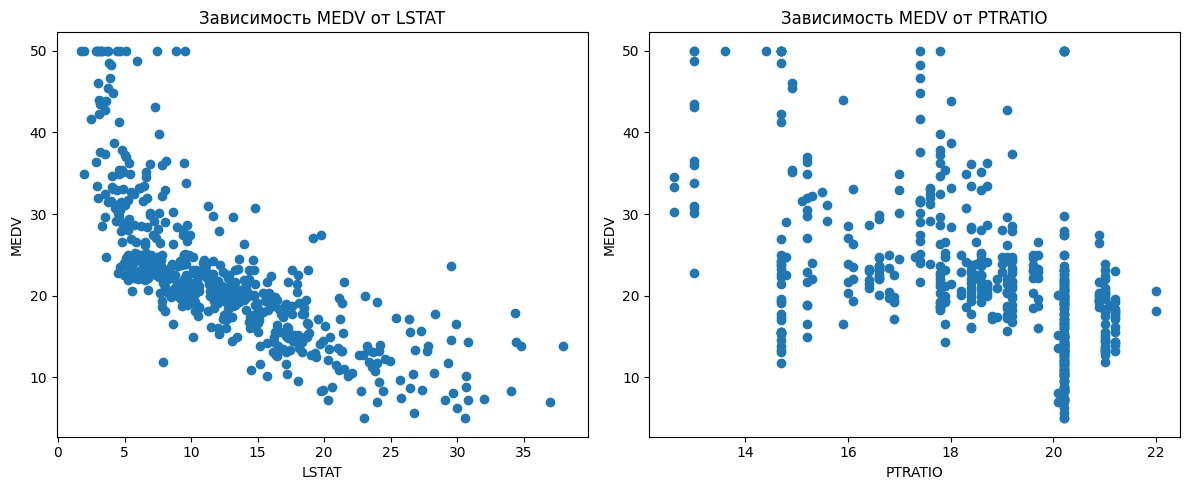

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(df['LSTAT'], df['MEDV'])
plt.xlabel('LSTAT')
plt.ylabel('MEDV')
plt.title('Зависимость MEDV от LSTAT')

plt.subplot(1, 2, 2)
plt.scatter(df['PTRATIO'], df['MEDV'])
plt.xlabel('PTRATIO')
plt.ylabel('MEDV')
plt.title('Зависимость MEDV от PTRATIO')

plt.tight_layout()
plt.show()

Из графиков видна зависимость между переменными.

#Задание 3.2.
Постройте модель линейной регрессии для предикторов LSTAT, PTRATIO. Оцените качество регрессии по RMSE и R2.

Линейная регрессия (LSTAT, PTRATIO):
RMSE: 5.66
R2: 0.57


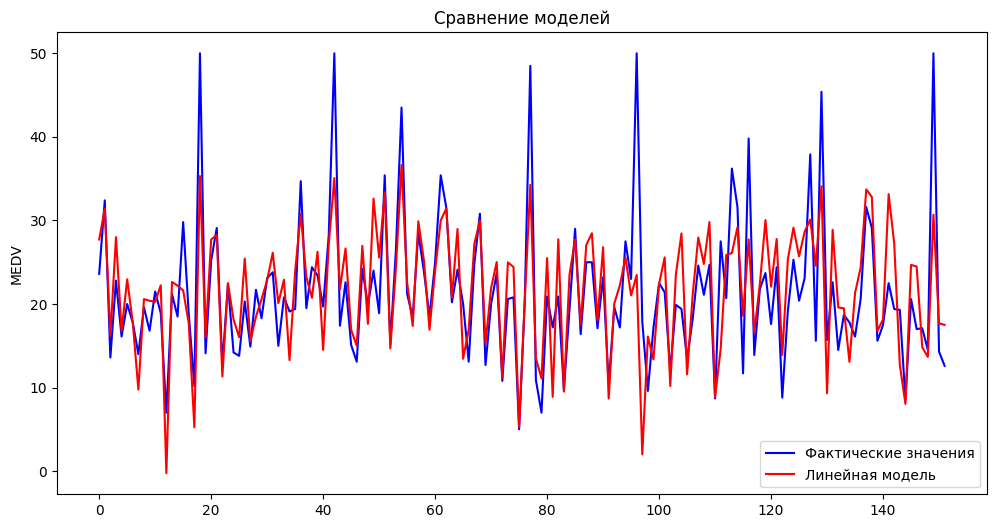

In [ ]:
# Выбор предикторов
X_train_lstat_ptratio = X_train[['LSTAT', 'PTRATIO']]
X_test_lstat_ptratio = X_test[['LSTAT', 'PTRATIO']]

# Обучение модели
lr = LinearRegression()
lr.fit(X_train_lstat_ptratio, y_train)

# Прогнозирование
y_pred = lr.predict(X_test_lstat_ptratio)

# Оценка качества
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f'Линейная регрессия (LSTAT, PTRATIO):')
print(f'RMSE: {rmse:.2f}')
print(f'R2: {r2:.2f}')

plt.figure(figsize=(12, 6))
x_points = np.arange(len(y_test))
plt.plot(x_points, y_test, color='blue', label='Фактические значения')
plt.plot(x_points, y_pred, color='red', label='Линейная модель')
plt.ylabel('MEDV')
plt.title('Сравнение моделей')
plt.legend()
plt.show()

#Задание 3.3.
Постройте модель линейной регрессии для предикторов согласно варианту. Оцените качество регрессии по RMSE и R2. Для чётного варианта используйте нелинейную модель полинома второй степени y = a*x2 +bx + c, для нечётного - экспоненциальную модель y =  a * eb*x, которую можно линеаризовать к виду ln(y) = c + d*x, где c = ln(a), d = ln(b)


Экспоненциальная модель (LSTAT, PTRATIO):
RMSE: 5.19
R2: 0.64


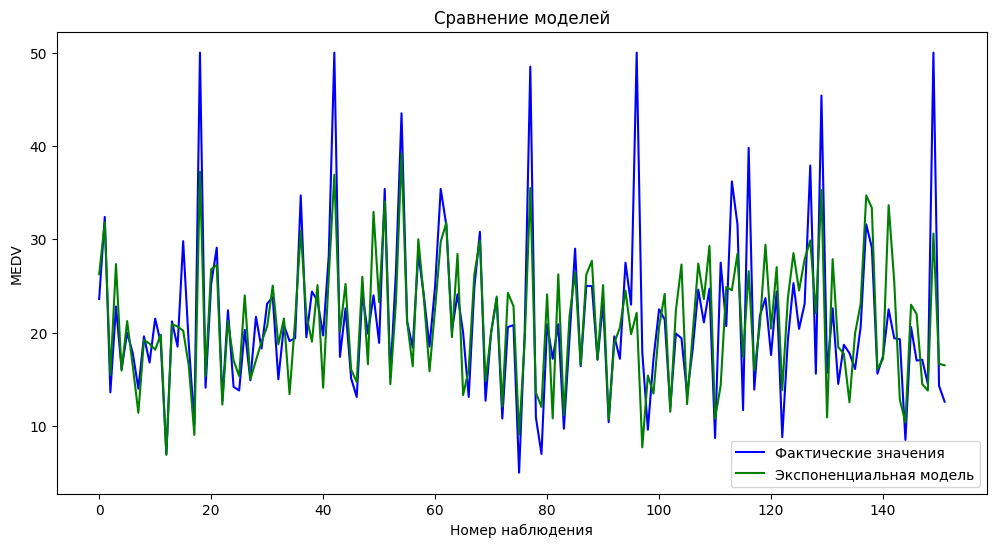

In [ ]:
# Линеаризация экспоненциальной модели y = a * e^(b*x)
# Преобразуем: ln(y) = ln(a) + b*x

# Создаем копии данных для преобразования
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# Обучаем модель на преобразованных данных
lr_exp = LinearRegression()
lr_exp.fit(X_train_lstat_ptratio, y_train_log)

# Прогнозирование и обратное преобразование
y_pred_log = lr_exp.predict(X_test_lstat_ptratio)
y_pred_exp = np.exp(y_pred_log)

# Оценка качества
rmse_exp = np.sqrt(mean_squared_error(y_test, y_pred_exp))
r2_exp = r2_score(y_test, y_pred_exp)

print(f'\nЭкспоненциальная модель (LSTAT, PTRATIO):')
print(f'RMSE: {rmse_exp:.2f}')
print(f'R2: {r2_exp:.2f}')

plt.figure(figsize=(12, 6))
x_points = np.arange(len(y_test))

plt.plot(x_points, y_test, color='blue', label='Фактические значения')
plt.plot(x_points, y_pred_exp, color='green', label='Экспоненциальная модель')
plt.xlabel('Номер наблюдения')
plt.ylabel('MEDV')
plt.title('Сравнение моделей')
plt.legend()
plt.show()

#Задание 4.1.
Постройте матрицу корреляции переменных в задаче. Какие из переменных сильнее всего влияют на целевую переменную (MEDV)? Модели последовательно постройте от каждого значимого параметра и их возможных комбинаций. Значимость определяется значением коэффициента корреляции (больше 0.5 по модулю). Оцените качество моделей регрессии по RMSE и R2.

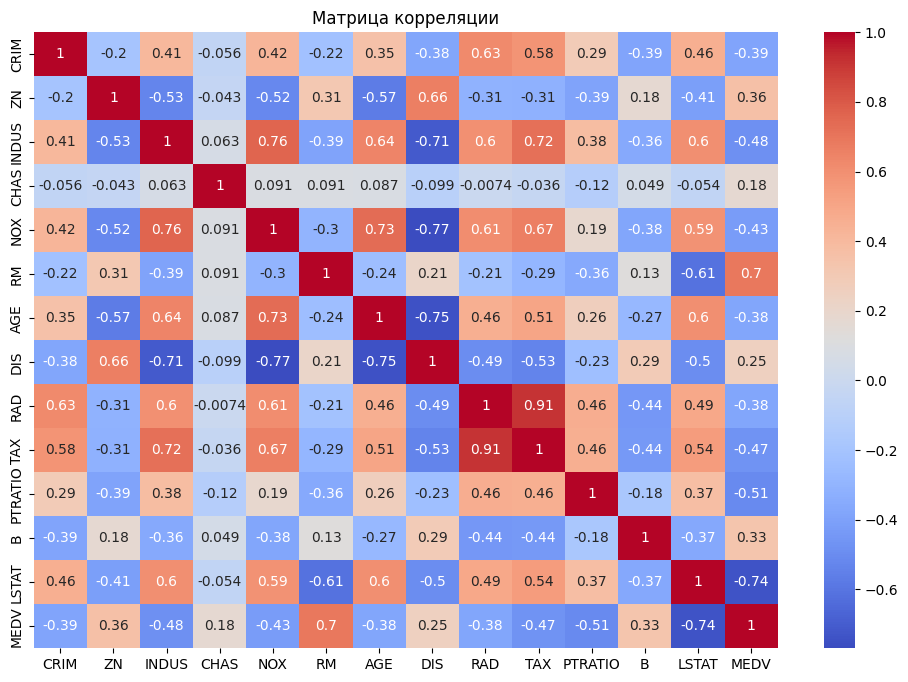

Значимые признаки: ['RM', 'PTRATIO', 'LSTAT']

Результаты для значимых признаков:
Тип модели           Признаки                       RMSE       R2        
Single               RM                             6.35       0.46      
Single               PTRATIO                        7.33       0.28      
Single               LSTAT                          6.17       0.49      
All significant      RM, PTRATIO, LSTAT             5.10       0.65      


In [ ]:
# Матрица корреляции
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Матрица корреляции')
plt.show()

# Выбор значимых признаков (|correlation| > 0.5 с MEDV)
significant_features = corr_matrix.index[abs(corr_matrix['MEDV']) > 0.5].drop('MEDV')
print(f'Значимые признаки: {list(significant_features)}')

# Построение моделей для значимых признаков и их комбинаций
results = []

for feature in significant_features:
    # Модель с одним признаком
    X_train_single = X_train[[feature]]
    X_test_single = X_test[[feature]]

    lr_single = LinearRegression()
    lr_single.fit(X_train_single, y_train)
    y_pred_single = lr_single.predict(X_test_single)

    rmse_single = np.sqrt(mean_squared_error(y_test, y_pred_single))
    r2_single = r2_score(y_test, y_pred_single)
    results.append(('Single', feature, rmse_single, r2_single))

# Модель со всеми значимыми признаками
X_train_sig = X_train[significant_features]
X_test_sig = X_test[significant_features]

lr_sig = LinearRegression()
lr_sig.fit(X_train_sig, y_train)
y_pred_sig = lr_sig.predict(X_test_sig)

rmse_sig = np.sqrt(mean_squared_error(y_test, y_pred_sig))
r2_sig = r2_score(y_test, y_pred_sig)
results.append(('All significant', ', '.join(significant_features), rmse_sig, r2_sig))

# Вывод результатов
print('\nРезультаты для значимых признаков:')
print('{:<20} {:<30} {:<10} {:<10}'.format('Тип модели', 'Признаки', 'RMSE', 'R2'))
for res in results:
    print('{:<20} {:<30} {:<10.2f} {:<10.2f}'.format(*res))

#Задание 4.2.
Возьмите все признаки и поместите их в переменную X. Целевую переменную MEDV поместите в переменную y. Постройте модель линейной регрессии для всех предикторов, влияющих на целевую переменную. Оцените качество регрессии по RMSE и R2.


Линейная регрессия (все признаки):
RMSE: 4.64
R2: 0.71


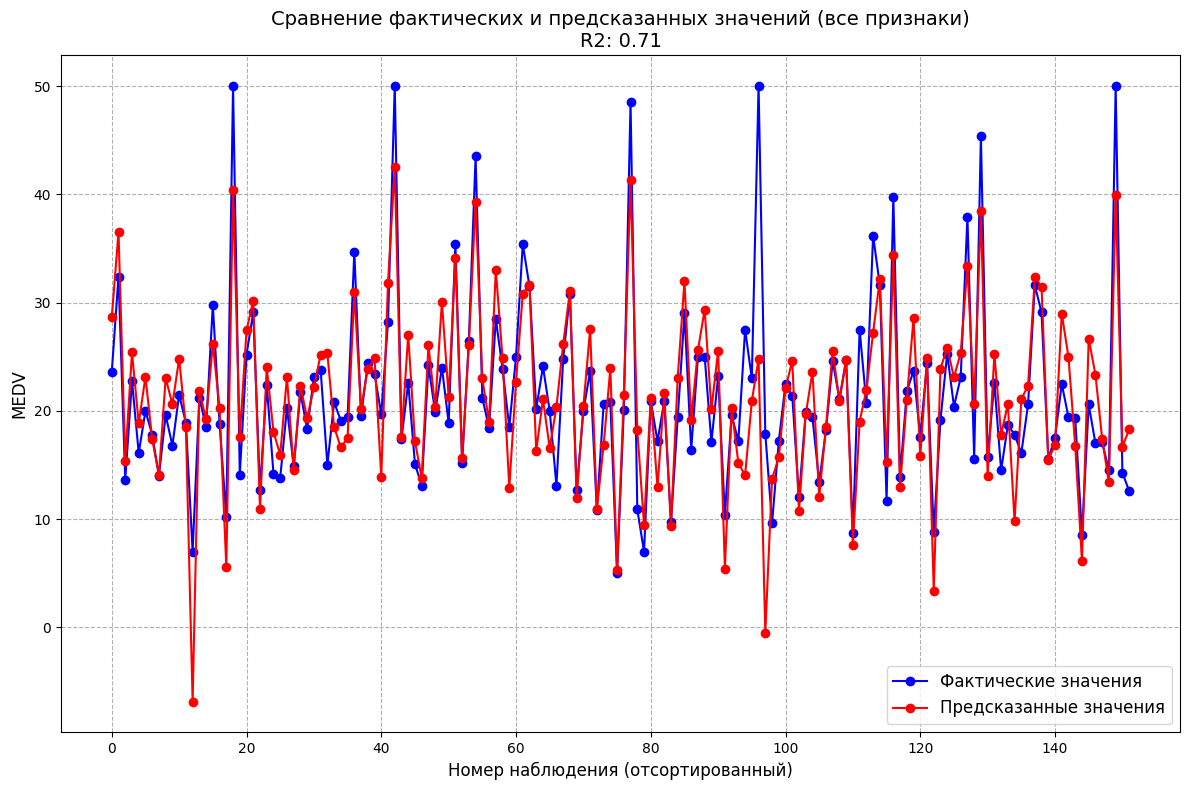

In [ ]:
# Модель со всеми признаками
lr_all = LinearRegression()
lr_all.fit(X_train, y_train)
y_pred_all = lr_all.predict(X_test)

rmse_all = np.sqrt(mean_squared_error(y_test, y_pred_all))
r2_all = r2_score(y_test, y_pred_all)

print(f'\nЛинейная регрессия (все признаки):')
print(f'RMSE: {rmse_all:.2f}')
print(f'R2: {r2_all:.2f}')

plt.figure(figsize=(12, 8))
plt.plot(range(len(y_test)), y_test, 'bo-', label='Фактические значения')
plt.plot(range(len(y_test)), y_pred_all, 'ro-', label='Предсказанные значения')
plt.xlabel('Номер наблюдения (отсортированный)', fontsize=12)
plt.ylabel('MEDV', fontsize=12)
plt.title(f'Сравнение фактических и предсказанных значений (все признаки)\nR2: {r2_all:.2f}', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

#Задание 4.3.
В сводной таблице сравните качество моделей регресии (из заданий 3.2, 3.3, 4.1, 4.2) на тестовой выборке по показателям R2 и RMSE. Как повлияло включение или исключение тех или иных предикторов на точность обученных моделей? Какие признаки более значимы? Как повлияло применение нелинейных моделей регрессии (в задании 3.2) на точность по сравнению с линейной моделью с теми же предикторами? Какая модель получилась наиболее точной?

In [ ]:
# Сводная таблица результатов
comparison = pd.DataFrame({
    'Модель': ['Линейная (LSTAT, PTRATIO)', 'Экспоненциальная (LSTAT, PTRATIO)',
               'Лучшая одиночная', 'Все значимые', 'Все признаки'],
    'RMSE': [rmse, rmse_exp, min([r[2] for r in results if r[0] == 'Single']), rmse_sig, rmse_all],
    'R2': [r2, r2_exp, max([r[3] for r in results if r[0] == 'Single']), r2_sig, r2_all]
})

print('\nСравнение моделей:')
print(comparison.sort_values('R2', ascending=False))


Сравнение моделей:
                              Модель      RMSE        R2
4                       Все признаки  4.638690  0.711226
3                       Все значимые  5.100217  0.650904
1  Экспоненциальная (LSTAT, PTRATIO)  5.194601  0.637864
0          Линейная (LSTAT, PTRATIO)  5.659786  0.570100
2                   Лучшая одиночная  6.172415  0.488698


#Задание 5.
Оцените качество моделей через R2. Какую долю изменчивости целевой переменной объясняет модель, учитывающая все признаки? Какая модель имеет наибольший R2? Чем это объясняется?

In [ ]:
print('\nДоля объясненной дисперсии (R2):')
print(f'Линейная (LSTAT, PTRATIO): {r2:.2f}')
print(f'Экспоненциальная (LSTAT, PTRATIO): {r2_exp:.2f}')
print(f'Лучшая одиночная: {max([r[3] for r in results if r[0] == "Single"]):.2f}')
print(f'Все значимые: {r2_sig:.2f}')
print(f'Все признаки: {r2_all:.2f}')


Доля объясненной дисперсии (R2):
Линейная (LSTAT, PTRATIO): 0.57
Экспоненциальная (LSTAT, PTRATIO): 0.64
Лучшая одиночная: 0.49
Все значимые: 0.65
Все признаки: 0.71


#Вывод
Наибольший R2 у модели со всеми признаками. Это объясняется тем, что она учитывает максимальное количество информации о данных.